## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import string
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## Loading the data

In [2]:
data_path = '../data/DANE.xlsx'

In [3]:
real_or_simulated = 'real'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inds', lsuffix='_inks')

### Removing some data

1. Let's remove rows with missing values.

In [8]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [9]:
inDKs_df.dropna(inplace=True)

In [10]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [11]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [12]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [13]:
indices = list(range(int(X.shape[0]/15)))

ind_train, ind_test = train_test_split(indices, test_size=0.3, random_state=1)
# ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
# ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)

In [14]:
ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
ind_train_all = [x for l in ind_train_all for x in l]
ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
ind_test_all = [x for l in ind_test_all for x in l]

In [15]:
# partition = {'train': ind_train,
#             'validation': ind_val,
#             'test': ind_test}

partition = {'train': ind_train_all,
            'test': ind_test_all}

In [16]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_test = X[partition['test']]
y_test = y[partition['test']]

## PCA visualisation of X_train and X_test

In [17]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

In [18]:
X_train_pca.shape 
#for simulated: 1680 samples projected to 2D space
#for real: 990 samples projected to 2D space

(1680, 2)

In [19]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [20]:
X_test_pca = pca.transform(X_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

In [21]:
%matplotlib notebook

<IPython.core.display.Javascript object>


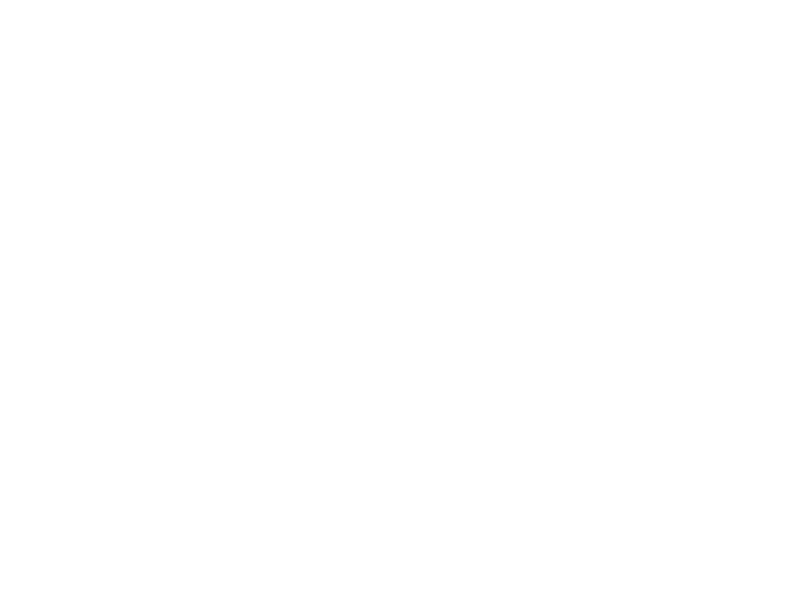

In [22]:
plt.plot(X_train_pca[:,0], X_train_pca[:,1], '.', markersize=10, label='X train')
plt.plot(X_test_pca[:,0], X_test_pca[:,1], '.', markersize=10, alpha=0.3, label='X test')
plt.legend()
plt.title('PCA projection')
plt.savefig('../results/visualisations/'+real_or_simulated + '_X.png')

## PCA visualisation of y_train and y_test

In [23]:
pca = PCA(n_components=2)
y_train_pca = pca.fit_transform(y_train)

In [24]:
y_train_pca.shape 
#for simulated: 1680 samples projected to 2D space
#for real: 990 samples projected to 2D space

(1680, 2)

In [25]:
pca.components_.shape
#first column tells us about how much first feature contributes to PC1, PC2
#second column tells us about how much second feature contributes to PC1, PC2

(2, 29)

In [26]:
y_test_pca = pca.transform(y_test) #transform instead of fit_transform!
#because we want to use this PCA that has already been calculated for X_train
#not the new one and new PC1, PC2, because then we cannot compare nor visualize

In [27]:
%matplotlib notebook

<IPython.core.display.Javascript object>


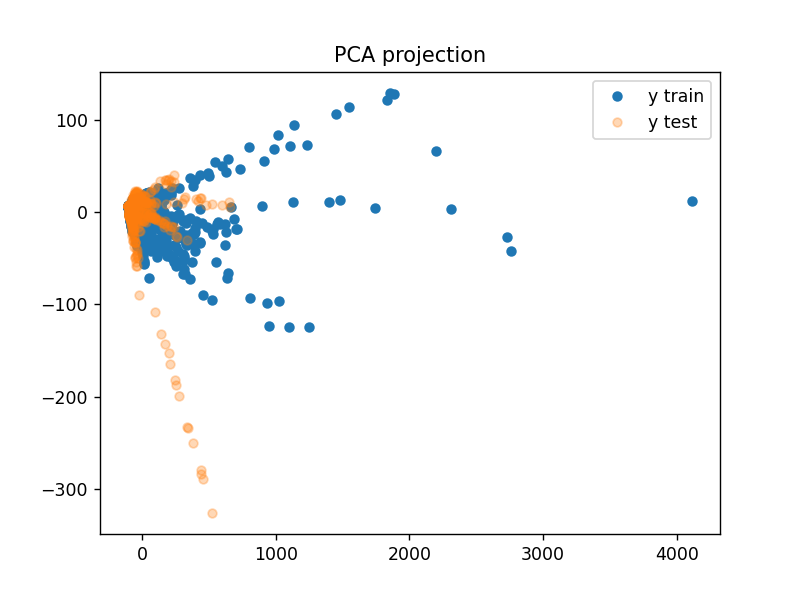

In [28]:
plt.plot(y_train_pca[:,0], y_train_pca[:,1], '.', markersize=10, label='y train')
plt.plot(y_test_pca[:,0], y_test_pca[:,1], '.', markersize=10, alpha=0.3, label='y test')
plt.legend()
plt.title('PCA projection')
plt.savefig('../results/visualisations/'+real_or_simulated + '_y.png')